# 完全保存用の独立した再実行

このNotebookは notebooks/10_svd/30_fashion_mnist_cnn/03_cnn_linear_svd_finetuning.ipynb の新規run。過去runの復元ではなく、baseline重み・全rankの未丸め値・FT各epoch履歴・測定条件を新しい出力先へ保存する。元の説明・条件・TODOを保持し、変更は出力先・進捗ログ・保存用セルだけ。

元Notebook中の「未実行」「過去の欠落」は複製元runへの説明。以下の新規runの実行状態は末尾のrun_manifest.jsonと各セルのexecution_countで確認する。

実行後の命名整理：Notebook名とEXPERIMENT_NAMEを `_rerun` に揃え、results/modelsの対応ディレクトリも改名した。学習・評価は再実行していない。セルの出力ログにある日時付き旧パスは実行当時の記録であり、現在の保存先はEXPERIMENT_NAMEとrun_manifest.jsonの各pathを参照する。数値・図・execution_countは改名前の実行結果を保持する。


In [1]:
# 独立した新規run。元Notebook/CSV/重みを上書きしない。
import sys
from pathlib import Path
_run_root = Path.cwd().resolve()
while not (_run_root / "src" / "nn_compression").is_dir() and _run_root.parent != _run_root:
    _run_root = _run_root.parent
sys.path.insert(0, str(_run_root / "src"))
RUN_BATCH_ID = 'rerun_20260912T074153Z'
RUN_SOURCE_RELATIVE = 'notebooks/10_svd/30_fashion_mnist_cnn/03_cnn_linear_svd_finetuning.ipynb'
RUN_NOTEBOOK_RELATIVE = 'notebooks/10_svd/30_fashion_mnist_cnn/03_cnn_linear_svd_finetuning_rerun.ipynb'
RUN_SOURCE_SNAPSHOT_SHA256 = '801f479fe6e5fb3aa24593c5dbca390ac2192680d1d42c7ac11f988eec278a57'
print("独立新規run:", RUN_BATCH_ID, RUN_SOURCE_RELATIVE)


独立新規run: rerun_20260912T074153Z notebooks/10_svd/30_fashion_mnist_cnn/03_cnn_linear_svd_finetuning.ipynb


# 03 CNN Linear SVD Fine-tuning — Fashion-MNIST

## 2026-09-12 保存成果物監査への対応

同一runのbaseline重みを学習直後に保存する処理を追加した。過去の保存出力は変更前runの記録であり、追加した保存処理は未実行。過去runの未保存baselineを別Notebookの重みで代用したり、再現できたことにはしていない。

保存出力の整合性と、現行コードのRun All成功は別の確認である。未実行の追加処理があるセルはexecution_countを空にし、既存outputは過去記録として保持した。


## 1. import

実験で使うライブラリと `nn_compression` の関数を読み込む。学習ループ・SVD・指標計算は Notebook 内に再定義しない。


In [2]:
# 標準ライブラリ
from __future__ import annotations
import copy
import itertools

from copy import deepcopy
from pathlib import Path
import json
import platform
import random
import sys

# データ処理・可視化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.preprocessing import MinMaxScaler
# ============================================================
# 【.py側をimport】元の03ではここに def / class を書いていた
# ============================================================
# SVD圧縮: CNN の fc1 置換は linear_svd.py、特異値エネルギーは svd.py
# make_two_layer_svd_model は 784→512→256 MLP 専用なのでここでは使わない
from nn_compression.compression.linear_svd import factorize_named_linear
from nn_compression.compression.svd import retained_energy
# データ準備: 元03では FashionMNIST / random_split / DataLoader を直書き
from nn_compression.datasets import (
    get_fashion_mnist_datasets,      # datasets/fashion_mnist.py
    make_fashion_mnist_loaders,      # 同上
    split_fashion_mnist_dataset,     # 同上
)

# 評価指標: 元03では各セルで def していた
from nn_compression.metrics import (
    accuracy_drop,           # metrics/model_comparison.py
    agreement,               # metrics/model_comparison.py
    benchmark_inference,     # metrics/model_comparison.py
    count_parameters,        # metrics/model_comparison.py
    logits_rmse,             # metrics/model_comparison.py
    parameters_reduction,    # metrics/model_comparison.py
    compressed_linear_macs,
    linear_macs,
    estimate_cnn_linear_macs,
)

# モデル: 元03では class MNISTMLP(nn.Module): をNotebook内に書いていた
from nn_compression.models import FashionMNISTCNN  # models/cnn.py

# Pareto / knee: 元03では GetPoint などをセル定義していた
# .py化に合わせて、Python標準の snake_case 名へ整理している
from nn_compression.selection import (
    extract_pareto_frontier, # selection/pareto.py
    find_knee_point,         # selection/knee.py
    get_first_point,         # selection/knee.py
    line_equation,           # selection/knee.py
)

# 学習: 元03では train_one_epoch / evaluate / Early Stoppingループを直書き
from nn_compression.training import (
    evaluate,                 # training/loops.py
    train_one_epoch,          # training/loops.py
    fit_with_early_stopping,  # training/fit.py（Early Stopping付き学習）
)

# パス・seed: 元03では find_project_root / set_seed をNotebook内に定義
from nn_compression.utils import (
    find_project_root,     # utils/paths.py
    get_experiment_dirs,   # utils/paths.py
    make_torch_generator,  # utils/seed.py
    set_seed,              # utils/seed.py
)


## 2. 再現性と実行デバイス

seed を 0 に固定し、CUDA / MPS / CPU から使うデバイスを決める。


In [3]:
# 再現性のため seed を固定する。MLP実験と同じ 0 にして比較しやすくする。
SEED = 0
# 【.py】utils/seed.py。Python / NumPy / PyTorch の乱数源をまとめて固定する
set_seed(SEED)

# 使えるハードウェアを優先順に選ぶ: CUDA GPU → Apple MPS → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 3. 保存先

`get_experiment_dirs` で data / models / results をプロジェクトルート基準に作る。02 を上書きしないよう、出力先は `03_cnn_linear_svd_finetuning`。


In [4]:
# MLP実験と同じく、プロジェクトルート基準で保存先を決める
# Path(".") だと Notebook の cwd 次第で data/results がズレる
# method-first の新しい構成に合わせて保存先を識別する。
METHOD_NAME = "10_svd"
CASE_NAME = "30_fashion_mnist_cnn"
EXPERIMENT_NAME = "03_cnn_linear_svd_finetuning_rerun"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    METHOD_NAME,
    CASE_NAME,
    EXPERIMENT_NAME,
)

# このNotebook内の既存変数名に合わせる
# 重み → models/..., CSV・図・metadata → results/...
checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z
results_dir: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z


## 4. Fashion-MNISTの読み込み

`ToTensor()` で画像を `(1, 28, 28)` のテンソルにする。公式の学習 60,000 枚を train / validation に分け、test 10,000 枚は最終評価まで使わない。


In [5]:
# 画像をPyTorchで扱える torch.Tensor に変換するための変換処理オブジェクトを作っています。
# Datasetに渡すと、各画像を取り出すたびにこの変換が適用されます。
# ToTensor(): PIL Image (28×28) → Tensor (1, 28, 28)、値域は [0, 1]
transform = transforms.ToTensor()

# 【.py】get_experiment_dirs が返した data/ を使う（cwd に依存しない）
data_root = data_dir

# train=True: 公式の学習用 60,000 枚。後で train / validation に分割する
full_train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

# train=False: 公式のテスト 10,000 枚。最終評価まで使わない
test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

train_size = 50_000
validation_size_early_stop = 5_000
validation_size_rank = 5_000

# random_split の分割結果を seed で固定する
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset_early_stop,validation_dataset_rank = random_split(
    full_train_dataset,
    lengths=[train_size, validation_size_early_stop,validation_size_rank],
    generator=split_generator,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation_early_stop: {len(validation_dataset_early_stop):,}")
print(f"validation_rank: {len(validation_dataset_rank):,}")
print(f"test:       {len(test_dataset):,}")


train:      50,000
validation_early_stop: 5,000
validation_rank: 5,000
test:       10,000


## 5. DataLoader

batch size 256、`num_workers=0` で学習・Early Stopping 用 validation・rank 比較用 validation・test のローダを作る。`train_loader` を `next(iter(...))` すると shuffle 用 Generator を消費するので、shape 確認は `train_dataset[0]` で行う。


In [6]:
BATCH_SIZE = 256
# データを読む・画像変換する・バッチ化するための子プロセス数です。
#0：メインプロセス自身がデータを読み込む。デバッグしやすく、Windows/Jupyterで問題を切り分けやすい
#1 以上：複数の子プロセスが次のバッチを並列に準備するため、ディスクI/Oや画像拡張が重い場合に学習待ち時間を減らせる
#増やしすぎると、CPU競合・メモリ使用量増加・プロセス起動のオーバーヘッドで、かえって遅くなることがある
#num_workers はGPU数ではなく、CPU側のデータ準備担当者の人数です。
# まず 0 で正しく動作を確認し、2, 4, 8 などを実測して、1 epochあたりの時間が最短になる値を選ぶのが確実です。
NUM_WORKERS = 0

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    #num_workers は、DataLoaderがデータを読み込み・前処理・バッチ化するために使う子プロセスの数です。
    # 大きくすると、次のバッチを並列に準備できるため、GPUがデータ待ちになる時間を減らせる場合があります。
    num_workers=NUM_WORKERS,
    # CUDA GPUを使うときだけ True にする設定です。
    # True なら、DataLoaderが返すCPUテンソルをページロック（pinned）メモリに置き、
    # CPUからGPUへの転送を速くしやすくします。
    # CPU側の転送用メモリを固定する設定です。
    # 小さなデータやCPU学習では効果が乏しく、ホストメモリの負担もあるため、CUDA時だけ有効にする現在の書き方がよいです。
    pin_memory=(device.type == "cuda"),
    # shuffle=True で使うランダムなデータ順序を制御する torch.Generator です。
    # 通常は再現性のためにシード固定済みのジェネレータを渡します。
    generator=loader_generator,
)

validation_loader_early_stop = DataLoader(
    validation_dataset_early_stop,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

validation_loader_rank = DataLoader(
    validation_dataset_rank,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loader を next(iter(...)) すると shuffle 用 Generator を消費するので避ける
image, label = train_dataset[0]
print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(f"batch images shape: ({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})")


image shape: (1, 28, 28)
label: 6
batch images shape: (256, 1, 28, 28)


## 6. CNNモデルの定義

Conv2d → ReLU → MaxPool を2回したあと Flatten し、`Linear(3136, 128)` → `Linear(128, 10)` で分類する。この Notebook の SVD 対象は `fc1`。


In [7]:
# FashionMNISTCNN は src/nn_compression/models/cnn.py から import 済み。
# 構造は Notebook 定義時と同じ:
# Conv(1→32) → Pool → Conv(32→64) → Pool → Linear(3136→128) → Linear(128, 10)


## 7. 総パラメータ数

CNN をデバイスへ載せ、学習可能な重みの総数を数える。この設計なら 421,642 になる。


In [8]:
baseline_model = FashionMNISTCNN().to(device)
# 【.py】metrics/model_comparison.py。学習可能・非学習可能を問わず全要素数を数える
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"parameters: {baseline_parameter_count:,}")

# モデルを上の設計通りに書けていれば421,642になる。
assert baseline_parameter_count == 421_642


parameters: 421,642


## 8. 層ごとのパラメータ数

`named_parameters()` で各層の shape と要素数を出し、`fc1` が大きいことを確認する。


In [9]:
# 各層のパラメータ数も確認する。
#named_parameters() は、
# PyTorchモデルの学習対象パラメータを
# 「名前」と「Tensor」の組で取り出すメソッドです。
# numel(): その Tensor の要素数 = その層のパラメータ数
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"params={parameter.numel():,}"
    )


conv1.weight         shape=(32, 1, 3, 3)      params=288
conv1.bias           shape=(32,)              params=32
conv2.weight         shape=(64, 32, 3, 3)     params=18,432
conv2.bias           shape=(64,)              params=64
fc1.weight           shape=(128, 3136)        params=401,408
fc1.bias             shape=(128,)             params=128
fc2.weight           shape=(10, 128)          params=1,280
fc2.bias             shape=(10,)              params=10


## 9. Baseline学習

多クラス分類なので `CrossEntropyLoss` と Adam を使い、Early Stopping 付きで Baseline CNN を学習する。


In [10]:
# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 30
PATIENCE=3
MIN_DELTA = 1e-4

# Adam: 学習率 0.001 はよく使う初期値
optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

baseline_fit = fit_with_early_stopping(
    baseline_model,
    train_loader,
    validation_loader_early_stop,
    criterion,
    optimizer,
    device,
    BASELINE_EPOCHS,
    PATIENCE,
    MIN_DELTA,
    log_every_epoch=True,
)

epoch=01 train_loss=0.4186 train_acc=0.8496 val_loss=0.4284 val_acc=0.8436


epoch=02 train_loss=0.3171 train_acc=0.8868 val_loss=0.3283 val_acc=0.8788


epoch=03 train_loss=0.2881 train_acc=0.8983 val_loss=0.3036 val_acc=0.8878


epoch=04 train_loss=0.2594 train_acc=0.9071 val_loss=0.2874 val_acc=0.8946


epoch=05 train_loss=0.2692 train_acc=0.9016 val_loss=0.2928 val_acc=0.8890


...

epoch=11 train_loss=0.1602 train_acc=0.9424 val_loss=0.2261 val_acc=0.9162


epoch=12 train_loss=0.1511 train_acc=0.9472 val_loss=0.2161 val_acc=0.9190


epoch=13 train_loss=0.1506 train_acc=0.9434 val_loss=0.2288 val_acc=0.9158


epoch=14 train_loss=0.1268 train_acc=0.9544 val_loss=0.2171 val_acc=0.9228


epoch=15 train_loss=0.1183 train_acc=0.9585 val_loss=0.2192 val_acc=0.9234
Early stopping at epoch 15


## 10. 学習履歴の保存

最良 epoch と validation loss を確認し、`fit_history.csv` と `fit_loss_history.csv` に書き出す。


In [11]:
# fit_with_early_stopping の学習履歴。CSV保存とグラフ用に取り出す
history = baseline_fit["history"]
train_loss_history = baseline_fit["train_loss_history"]
validation_loss_history = baseline_fit["validation_loss_history"]
best_epoch = baseline_fit["best_epoch"]
best_validation_loss = baseline_fit["best_validation_loss"]
df_training_history = pd.DataFrame(history)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)
print(f"epochs recorded: {len(history)}")

# epochごとの詳細履歴（loss / acc）
history_csv = csv_dir / "fit_history.csv"
df_training_history.to_csv(history_csv, index=False)

# 戻り値の1次元リストも保存しておく
loss_history_csv = csv_dir / "fit_loss_history.csv"
pd.DataFrame(
    {
        "epoch": list(range(1, len(train_loss_history) + 1)),
        "train_loss": train_loss_history,
        "validation_loss": validation_loss_history,
    }
).to_csv(loss_history_csv, index=False)

print("saved:", history_csv)
print("saved:", loss_history_csv)



best epoch: 12
best validation loss: 0.2161
epochs recorded: 15
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\fit_history.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\fit_loss_history.csv


## 11. 学習曲線

履歴を表で表示し、loss / accuracy の epoch 推移を描く。最良重みの `state_dict` も控えておく。


Best epoch: 12
Best validation loss: 0.2161


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.84964,0.418617,0.428412,0.8436
1,2,0.88678,0.317131,0.328291,0.8788
2,3,0.89830,0.288111,0.303559,0.8878
3,4,0.90708,0.259362,0.287403,0.8946
4,5,0.90160,0.269245,0.292842,0.8890
5,6,0.91728,0.226969,0.265746,0.9008
6,7,0.91380,0.231875,0.263118,0.8966
7,8,0.92964,0.193439,0.234303,0.9090
8,9,0.93430,0.181467,0.230178,0.9138
9,10,0.93550,0.179677,0.234276,0.9088


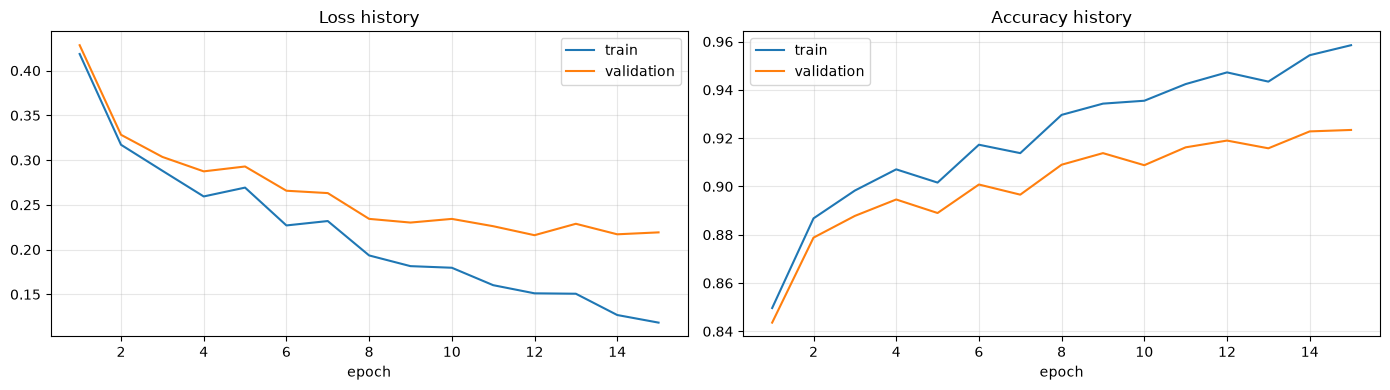

In [12]:
from IPython.display import display

model = baseline_fit["model"]
baseline_state = copy.deepcopy(model.state_dict())
# 監査対応: 同じrunのbaselineをRAMだけでなく保存する。再学習せず再検証できるようにする。
baseline_checkpoint_path = models_dir / "baseline_same_run.pt"
torch.save(baseline_state, baseline_checkpoint_path)


# 【.ipynb側】履歴を DataFrame / グラフにするのは実験ノートの仕事
df_training_history = pd.DataFrame(baseline_fit["history"])

print("Best epoch:", baseline_fit["best_epoch"])
print(f"Best validation loss: {baseline_fit['best_validation_loss']:.4f}")
display(df_training_history)

fig_learning, axes_learning = plt.subplots(1, 2, figsize=(14, 4))
axes_learning[0].plot(df_training_history["epoch"], df_training_history["train_loss"], label="train")
axes_learning[0].plot(df_training_history["epoch"], df_training_history["validation_loss"], label="validation")
axes_learning[0].set_title("Loss history")
axes_learning[0].set_xlabel("epoch")
axes_learning[0].legend()
axes_learning[0].grid(True, alpha=0.3)

axes_learning[1].plot(df_training_history["epoch"], df_training_history["train_acc"], label="train")
axes_learning[1].plot(df_training_history["epoch"], df_training_history["validation_acc"], label="validation")
axes_learning[1].set_title("Accuracy history")
axes_learning[1].set_xlabel("epoch")
axes_learning[1].legend()
axes_learning[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. MACsの見積もり

`fc1` を `Linear(in → rank)` + `Linear(rank → out)` に分解したときの MACs と削減率を、元の Linear と比較して出す。02 / 03 の比較対象は `fc1` と `fc2` のみ。


In [13]:
# この処理は src/nn_compression から import 済み。


In [14]:
# この処理は src/nn_compression から import 済み。


## 14. SVD rank sweep

`fc1` の rank 候補を走査し、圧縮直後（未学習）の validation loss / acc、パラメータ削減、agreement などを表にまとめる。


In [15]:
R1_LIST = [16,20,24,28,32,36,42,44,48,64,80,96,112,128]  # fc1 の rank 候補
#R2_LIST = [10]       # fc2 の rank 候補

#rank_configs = list(itertools.product(R1_LIST,R2_LIST))  # 【.ipynb】実験条件

# 【.py】metrics/model_comparison.py / metrics/mlp_macs.py
baseline_time_s = benchmark_inference(
    model,
    validation_loader_rank,
    device,
    warmup=20,    # 【.ipynb】ベンチ条件
    repeats=2000, # 【.ipynb】ベンチ条件
)
# 【.py】training/loops.py
baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)

rank_results = []
for fc1_rank in R1_LIST:
    
    compressed_model = factorize_named_linear(
        model,
        "fc1",
        fc1_rank,
    )

    validation_loss, validation_acc = evaluate(
        compressed_model,
        validation_loader_rank,
        criterion,
        device,
    )
    # 【.py】metrics/*
    drop = accuracy_drop(
        baseline_rank_validation_acc,
        validation_acc,
        verbose=False,
    )
    # 【.py】metrics/mlp_macs.py
    _, compressed_macs, compute_reduction = estimate_cnn_linear_macs(
        model,
        fc1_rank,
        verbose=False,
    )
    compressed_time_s = benchmark_inference(
        compressed_model,
        validation_loader_rank,
        device,
        warmup=20,
        repeats=2000,
    )

    # 【.ipynb側】どの列を結果表に入れるかは実験設計
    row = {
        "fc1_rank": fc1_rank,
        "parameters": count_parameters(compressed_model),
        "parameters_reduction": parameters_reduction(model, compressed_model),
        "validation_loss": validation_loss,
        "validation_acc": validation_acc,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        "agreement": agreement(model, compressed_model, validation_loader_rank, device),
        "logits_rmse": logits_rmse(model, compressed_model, validation_loader_rank, device),
        "retained_energy_fc1": retained_energy(model.fc1, fc1_rank),
        "model": compressed_model,
    }
    rank_results.append(row)
    print(
        f"r1={fc1_rank:3d}| "
        f"Acc={validation_acc:.4f} loss={validation_loss:.4f} | "
        f"params={row['parameters']} MACs={compressed_macs} | "
        f"agreement={row['agreement']:.4f}"
    )

print(f"\n集計完了: {len(rank_results)} 件")


r1= 16| Acc=0.8960 loss=0.2906 | params=72458 MACs=53504 | agreement=0.9344


r1= 20| Acc=0.9170 loss=0.2336 | params=85514 MACs=66560 | agreement=0.9708


r1= 24| Acc=0.9170 loss=0.2289 | params=98570 MACs=79616 | agreement=0.9790


r1= 28| Acc=0.9182 loss=0.2251 | params=111626 MACs=92672 | agreement=0.9854


r1= 32| Acc=0.9196 loss=0.2242 | params=124682 MACs=105728 | agreement=0.9870


...

r1= 64| Acc=0.9220 loss=0.2207 | params=229130 MACs=210176 | agreement=0.9956


r1= 80| Acc=0.9204 loss=0.2206 | params=281354 MACs=262400 | agreement=0.9984


r1= 96| Acc=0.9208 loss=0.2207 | params=333578 MACs=314624 | agreement=0.9994


r1=112| Acc=0.9214 loss=0.2206 | params=385802 MACs=366848 | agreement=0.9996


r1=128| Acc=0.9214 loss=0.2207 | params=438026 MACs=419072 | agreement=1.0000

集計完了: 14 件


## 15. Pareto frontier

パラメータ数が baseline 以下で、かつ計算量が減っている点だけを残し、validation loss との非劣後点を正規化して散布図にする。`model` 列は CSV に書かない。


pareto points: 9


,fc1_rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,16,72458,0.290595,0.0000,1.000000
1,20,85514,0.233623,0.0625,0.185757
2,24,98570,0.228873,0.1250,0.117875
3,28,111626,0.225110,0.1875,0.064086
4,32,124682,0.224240,0.2500,0.051662
5,44,163850,0.223805,0.4375,0.045437
6,48,176906,0.222365,0.5000,0.024857
7,64,229130,0.220670,0.7500,0.000640
8,80,281354,0.220626,1.0000,0.000000


saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\rank_sweep_results.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\pareto_frontier.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\parameters_vs_validation_loss_normalize.png


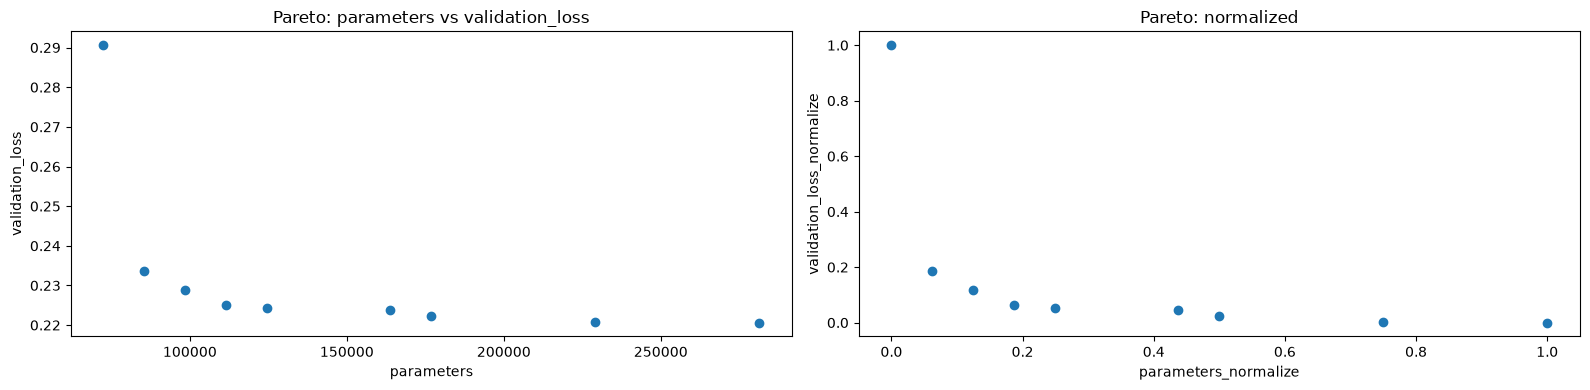

In [16]:
# ============================================================
# 【.ipynb側】前処理フィルタ・正規化・プロット
# 【.py側】Pareto frontier抽出だけ extract_pareto_frontier に任せる
# 元03では dominated判定の for ループをNotebook内に書いていた
# ============================================================
baseline_params = count_parameters(model)  # 【.py】metrics/model_comparison.py
df_rank_results = pd.DataFrame(rank_results)

# 【.ipynb側】「baselineより大きいparamsを落とす」等は実験判断
df_pareto_input = df_rank_results[
    (df_rank_results["parameters"] <= baseline_params)
    & (df_rank_results["compute_reduction"] > 0)
].copy()

# 【.py】selection/pareto.py
# 両目的とも小さいほど良い場合の非劣後点を返す
df_pareto_view = extract_pareto_frontier(
    df_pareto_input,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】どの列を正規化するかは実験設計
scaler = MinMaxScaler()
df_pareto_view[
    ["parameters_normalize", "validation_loss_normalize"]
] = scaler.fit_transform(
    df_pareto_view[["parameters", "validation_loss"]]
)

# 【.ipynb側】可視化
fig_pareto, axes_pareto = plt.subplots(1, 2, figsize=(16, 4))
axes_pareto[0].scatter(
    df_pareto_view["parameters"],
    df_pareto_view["validation_loss"],
)
axes_pareto[0].set_xlabel("parameters")
axes_pareto[0].set_ylabel("validation_loss")
axes_pareto[0].set_title("Pareto: parameters vs validation_loss")

axes_pareto[1].scatter(
    df_pareto_view["parameters_normalize"],
    df_pareto_view["validation_loss_normalize"],
)
axes_pareto[1].set_xlabel("parameters_normalize")
axes_pareto[1].set_ylabel("validation_loss_normalize")
axes_pareto[1].set_title("Pareto: normalized")
plt.tight_layout()

print("pareto points:", len(df_pareto_view))
display(
    df_pareto_view[
        [
            "fc1_rank",
            "parameters",
            "validation_loss",
            "parameters_normalize",
            "validation_loss_normalize",
        ]
    ]
)

# 【.py】results_dir は get_experiment_dirs（utils/paths.py）
# 【.ipynb側】ファイル名と「model列はCSVに書かない」は実験判断
# MLP 02 と同じ成果物名で、このセルの結果を保存する
results_dir.mkdir(parents=True, exist_ok=True)
rank_sweep_path = results_dir / "rank_sweep_results.csv"
pareto_path = results_dir / "pareto_frontier.csv"
pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"

df_rank_results.drop(columns=["model"], errors="ignore").to_csv(
    rank_sweep_path,
    index=False,
)
df_pareto_view.drop(columns=["model"], errors="ignore").to_csv(
    pareto_path,
    index=False,
)
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")

print("saved:", rank_sweep_path)
print("saved:", pareto_path)
print("saved:", pareto_figure_path)
plt.show()


## 16. knee ±1

正規化 Pareto の端点を結ぶ直線から最も遠い点を knee とし、その前後1点も次の候補にする。


In [17]:
# ============================================================
# 【.py】get_first_point / line_equation / find_knee_point
# 元03の GetPoint / GetlinearEquation / GetKneePoint_loop を
# Python標準の snake_case 名へ整理して移植
# 【.ipynb側】knee±1を候補にする、という実験判断はここに残す
# ============================================================

# 【.py】selection/knee.py
# get_first_point: 指定列でソートした先頭点の座標を返す
p0 = get_first_point(
    df_pareto_view,
    "parameters_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)
p1 = get_first_point(
    df_pareto_view,
    "validation_loss_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)

# 端点を結ぶ直線から最も遠い点が knee
knee_point, knee_distance = find_knee_point(
    df_pareto_view,
    *line_equation(p0, p1),
    "parameters_normalize",
    "validation_loss_normalize",
)

# 【.ipynb側】kneeの前後1点もFine-tuning候補にする
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)
knee_mask = (
    (df_pareto_view["parameters_normalize"] == knee_point[0])
    & (df_pareto_view["validation_loss_normalize"] == knee_point[1])
)
knee_pos = int(df_pareto_view.index[knee_mask][0])
left = max(knee_pos - 1, 0)
right = min(knee_pos + 1, len(df_pareto_view) - 1)

df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

print("knee distance:", knee_distance)
print(f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}]")
print("knee:")
display(df_pareto_knee.drop(columns="model"))
print("knee ±1:")
display(df_pareto_best.drop(columns="model"))

knee distance: 0.5353679481792101
knee_pos=2, neighbors iloc[1:4]
knee:


,fc1_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,parameters_normalize,validation_loss_normalize
2,24,98570,0.766223,0.228873,0.917,0.0044,79616,0.802289,0.346239,0.332059,0.979,0.610112,0.864688,0.125,0.117875


knee ±1:


,fc1_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,parameters_normalize,validation_loss_normalize
1,20,85514,0.797188,0.233623,0.9170,0.0044,66560,0.834711,0.346239,0.331435,0.9708,1.020363,0.839512,0.0625,0.185757
2,24,98570,0.766223,0.228873,0.9170,0.0044,79616,0.802289,0.346239,0.332059,0.9790,0.610112,0.864688,0.1250,0.117875
3,28,111626,0.735259,0.225110,0.9182,0.0032,92672,0.769866,0.346239,0.340989,0.9854,0.444652,0.883241,0.1875,0.064086


## 17. Fine-tuning（knee ±1）

SVD 圧縮した候補ごとに optimizer と seed を作り直し、Early Stopping で Fine-tuning する。構造が変わっているので optimizer は使い回さない。


In [18]:
# ============================================================
# 【.ipynb側】どの候補をFine-tuningするか、候補ごとの seed / optimizer
# 【.py側】学習ループ本体は fit_with_early_stopping を再利用
# 元03では for re_epoch in range(MAX_EPOCHS): を直書きしていた
# ============================================================
set_seed(SEED)
fine_tuned_records = []
LEARNING_RATE=3e-4
MAX_EPOCHS = 30

for _, pareto_row in df_pareto_best.iterrows():
    fc1_rank = int(pareto_row["fc1_rank"])
    fine_tuned_model = copy.deepcopy(pareto_row["model"]).to(device)

    candidate_optimizer = torch.optim.Adam(
        fine_tuned_model.parameters(),
        lr=LEARNING_RATE,
    )

    # 各rankを同じ乱数条件・shuffle順で比較
    set_seed(SEED)
    loader_generator.manual_seed(SEED)
    print(f"\n=== fine-tune r1={fc1_rank} ===")

    # 【.py】training/fit.py を baseline 学習と同じく再利用
    fit_result = fit_with_early_stopping(
        model=fine_tuned_model,
        train_loader=train_loader,
        val_loader=validation_loader_early_stop,  # Early Stopping用（rank用ではない）
        criterion=criterion,
        optimizer=candidate_optimizer,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        log_every_epoch=True,
    )

    fine_tuned_records.append(
        {
            "fc1_rank": fc1_rank,
            "best_epoch": fit_result["best_epoch"],
            "best_validation_loss": fit_result["best_validation_loss"],
            "history": fit_result["history"],
            "model": fit_result["model"],
        }
    )

df_fine_tuned_models = pd.DataFrame(fine_tuned_records)
display(df_fine_tuned_models.drop(columns=["history", "model"]))


=== fine-tune r1=20 ===


epoch=01 train_loss=0.1463 train_acc=0.9488 val_loss=0.2185 val_acc=0.9194


epoch=02 train_loss=0.1516 train_acc=0.9443 val_loss=0.2310 val_acc=0.9148


epoch=03 train_loss=0.1532 train_acc=0.9435 val_loss=0.2330 val_acc=0.9144


epoch=04 train_loss=0.1291 train_acc=0.9542 val_loss=0.2293 val_acc=0.9194
Early stopping at epoch 4

=== fine-tune r1=24 ===


...

epoch=01 train_loss=0.1402 train_acc=0.9516 val_loss=0.2134 val_acc=0.9196


epoch=02 train_loss=0.1457 train_acc=0.9463 val_loss=0.2269 val_acc=0.9182


epoch=03 train_loss=0.1482 train_acc=0.9456 val_loss=0.2332 val_acc=0.9132


epoch=04 train_loss=0.1259 train_acc=0.9556 val_loss=0.2294 val_acc=0.9174
Early stopping at epoch 4


,fc1_rank,best_epoch,best_validation_loss
0,20,1,0.218535
1,24,1,0.214128
2,28,1,0.213367


## 18. Fine-tuning前後の比較

候補を Aggressive / Balanced / Conservative と名付け、validation 上の acc / loss の変化を表とグラフにする。



=== fine-tune r1=20 ===



=== fine-tune r1=24 ===



=== fine-tune r1=28 ===


,candidate,fc1_rank,acc_before,acc_after,delta_acc,loss_before,loss_after,delta_loss
0,Aggressive,20,0.9170,0.9220,0.0050,0.233623,0.218242,-0.015381
1,Balanced,24,0.9170,0.9206,0.0036,0.228873,0.218888,-0.009986
2,Conservative,28,0.9182,0.9228,0.0046,0.225110,0.217010,-0.008100


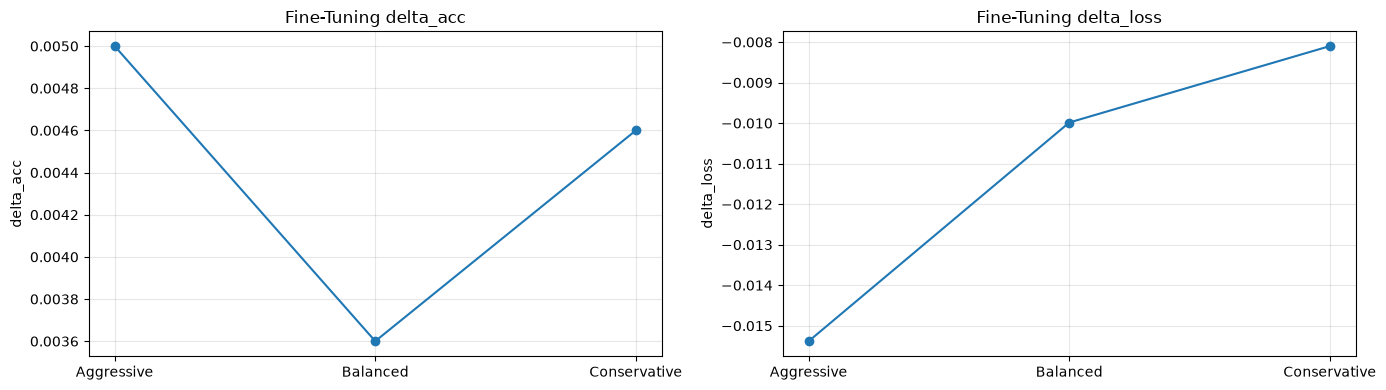

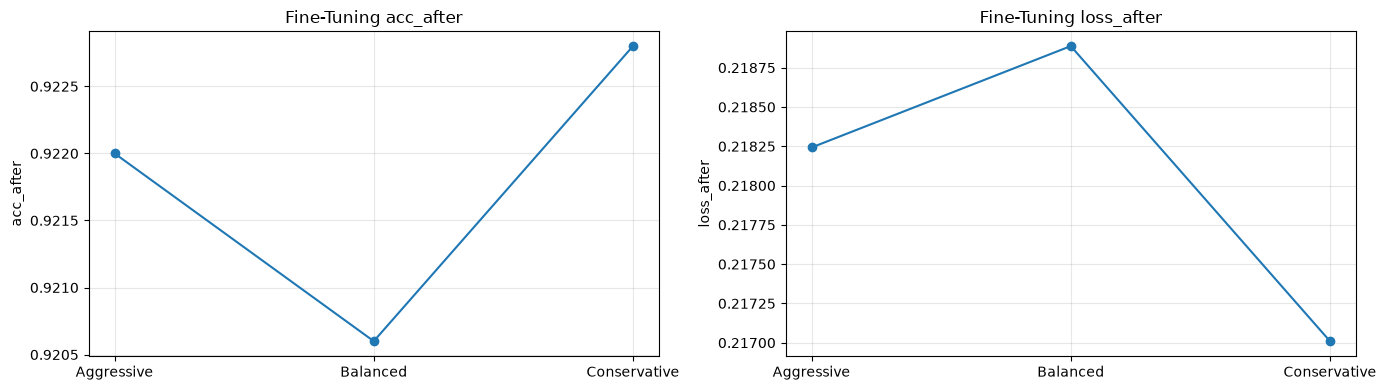

In [19]:
# ============================================================
# 【.ipynb側】候補名付け・比較表・グラフ（実験固有）
# 【.py側】evaluate だけ再利用
# ============================================================
fine_tuning_records = []

for idx, pareto_row in df_pareto_best.iterrows():
    fc1_rank = int(pareto_row["fc1_rank"])

    # 【.ipynb側】kneeより左/本体/右のラベル（元03と同じ）
    if idx < knee_pos:
        candidate = "Aggressive"
    elif idx == knee_pos:
        candidate = "Balanced"
    else:
        candidate = "Conservative"

    matched = df_fine_tuned_models[
        (df_fine_tuned_models["fc1_rank"] == fc1_rank)
    ]
    if len(matched) != 1:
        raise ValueError(
            f"Fine-tuning済みモデルが一意に見つかりません: "
            f"r1={fc1_rank} matches={len(matched)}"
        )
    print(f"\n=== fine-tune r1={fc1_rank} ===")
    # 【.py】evaluate。比較は Early Stopping用ではなく validation_loader_rank
    loss_after, acc_after = evaluate(
        matched.iloc[0]["model"],
        validation_loader_rank,
        criterion,
        device,
    )
    acc_before = float(pareto_row["validation_acc"])
    loss_before = float(pareto_row["validation_loss"])

    fine_tuning_records.append(
        {
            "candidate": candidate,
            "fc1_rank": fc1_rank,
            "acc_before": acc_before,
            "acc_after": acc_after,
            "delta_acc": acc_after - acc_before,
            "loss_before": loss_before,
            "loss_after": loss_after,
            "delta_loss": loss_after - loss_before,
        }
    )

df_fine_tuning_result = pd.DataFrame(fine_tuning_records)
display(df_fine_tuning_result)

# 【.ipynb側】可視化
fig_delta, axes_delta = plt.subplots(1, 2, figsize=(14, 4))
axes_delta[0].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["delta_acc"], marker="o")
axes_delta[0].set_title("Fine-Tuning delta_acc")
axes_delta[0].set_ylabel("delta_acc")
axes_delta[0].grid(True, alpha=0.3)
axes_delta[1].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["delta_loss"], marker="o")
axes_delta[1].set_title("Fine-Tuning delta_loss")
axes_delta[1].set_ylabel("delta_loss")
axes_delta[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig_after, axes_after = plt.subplots(1, 2, figsize=(14, 4))
axes_after[0].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["acc_after"], marker="o")
axes_after[0].set_title("Fine-Tuning acc_after")
axes_after[0].set_ylabel("acc_after")
axes_after[0].grid(True, alpha=0.3)
axes_after[1].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["loss_after"], marker="o")
axes_after[1].set_title("Fine-Tuning loss_after")
axes_after[1].set_ylabel("loss_after")
axes_after[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 19. 最終モデル選択と Test 評価

Fine-tuning 後の Pareto から最終1モデルを選び、ここで初めて test を Baseline と比較する。


In [20]:
# ============================================================
# 【.ipynb側】比較表の組み立て・最終選択ルール
# 【.py側】extract_pareto_frontier / evaluate / count_parameters を再利用
# ============================================================
df_candidate_params = df_pareto_best[
    ["fc1_rank", "parameters", "parameters_reduction"]
].copy()
df_after_comparison = df_fine_tuning_result.merge(
    df_candidate_params,
    on=["fc1_rank"],
    how="left",
    validate="one_to_one",
)

comparison_records = [
    {
        "model": "Baseline",
        "fc1_rank": "-",
        "validation_acc": baseline_rank_validation_acc,
        "validation_loss": baseline_rank_validation_loss,
        "parameters": baseline_params,
        "parameters_reduction": 0.0,
    }
]
for _, row in df_after_comparison.iterrows():
    comparison_records.append(
        {
            "model": f"{row['candidate']} after FT",
            "fc1_rank": int(row["fc1_rank"]),
            "validation_acc": row["acc_after"],
            "validation_loss": row["loss_after"],
            "parameters": int(row["parameters"]),
            "parameters_reduction": row["parameters_reduction"],
        }
    )

df_model_comparison = pd.DataFrame(comparison_records)
display(df_model_comparison)

# Baselineは圧縮モデルの選択対象から除外
df_final_candidates = df_model_comparison[
    df_model_comparison["model"] != "Baseline"
].copy()

# 【.py】selection/pareto.py を再度利用
df_final_pareto = extract_pareto_frontier(
    df_final_candidates,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】最終1モデルの優先順位（元03と同じ）
df_final_pareto = df_final_pareto.sort_values(
    by=["validation_loss", "parameters", "validation_acc"],
    ascending=[True, True, False],
).reset_index(drop=True)

final_model_result = df_final_pareto.iloc[0]
final_fc1_rank = int(final_model_result["fc1_rank"])
final_model = df_fine_tuned_models.loc[
    (df_fine_tuned_models["fc1_rank"] == final_fc1_rank),
    "model",
].iloc[0]

print("Selected final model:")
display(df_final_pareto.iloc[[0]])
print(f"Final model: r1={final_fc1_rank}")

# 最終選択後にTestを評価
final_test_loss, final_test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)
baseline_model_for_test = FashionMNISTCNN().to(device)
baseline_model_for_test.load_state_dict(baseline_state)
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model_for_test,
    test_loader,
    criterion,
    device,
)

df_test_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "fc1_rank": "-",
            "parameters": baseline_params,
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
            "delta_test_acc": 0.0,
            "delta_test_loss": 0.0,
        },
        {
            "model": "Final (compressed + FT)",
            "fc1_rank": final_fc1_rank,
            "parameters": count_parameters(final_model),
            "test_loss": final_test_loss,
            "test_acc": final_test_acc,
            "delta_test_acc": final_test_acc - baseline_test_acc,
            "delta_test_loss": final_test_loss - baseline_test_loss,
        },
    ]
)
display(df_test_comparison)


,model,fc1_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Baseline,-,0.9214,0.220664,421642,0.000000
1,Aggressive after FT,20,0.9220,0.218242,85514,0.797188
2,Balanced after FT,24,0.9206,0.218888,98570,0.766223
3,Conservative after FT,28,0.9228,0.217010,111626,0.735259


Selected final model:


,model,fc1_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Conservative after FT,28,0.9228,0.21701,111626,0.735259


Final model: r1=28


,model,fc1_rank,parameters,test_loss,test_acc,delta_test_acc,delta_test_loss
0,Baseline,-,421642,0.238263,0.9128,0.0000,0.00000
1,Final (compressed + FT),28,111626,0.234693,0.9149,0.0021,-0.00357


## 20. 結果の保存

Fine-tuning 結果、Test 比較、最終モデルの重みを `03_cnn_linear_svd_finetuning` へ保存する。CSV の `model` 列が PyTorch オブジェクトのときは落とす。


In [21]:
# ============================================================
# 【.ipynb側】何をどのファイル名で残すか（実験固有）
# 【.py側】results_dir / models_dir は get_experiment_dirs が用意済み
# ------------------------------------------------------------
# PyTorch の model オブジェクトは CSV に書かない。
# model_comparison / test_comparison の model 列は名前の文字列なので残す。
# ============================================================
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


def _drop_model_col(df):
    """CSV 向けに model 列を除いたコピーを返す"""
    return df.drop(columns=["model"], errors="ignore")


selected_path = results_dir / "selected_rank.csv"
neighbors_path = results_dir / "selected_rank_neighbors.csv"
fine_tuning_csv = results_dir / "fine_tuning_result.csv"
test_comparison_csv = results_dir / "test_comparison.csv"
model_comparison_csv = results_dir / "model_comparison.csv"
selected_final_csv = results_dir / "selected_final_model.csv"

_drop_model_col(df_rank_results).to_csv(
    results_dir / "rank_sweep_results.csv",
    index=False,
)
_drop_model_col(df_pareto_view).to_csv(
    results_dir / "pareto_frontier.csv",
    index=False,
)
_drop_model_col(df_pareto_knee).to_csv(selected_path, index=False)
_drop_model_col(df_pareto_best).to_csv(neighbors_path, index=False)

df_fine_tuning_result.to_csv(fine_tuning_csv, index=False)
df_test_comparison.to_csv(test_comparison_csv, index=False)
df_model_comparison.to_csv(model_comparison_csv, index=False)
pd.DataFrame([final_model_result]).to_csv(selected_final_csv, index=False)

pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"
delta_figure_path = results_dir / "fine_tuning_delta.png"
after_figure_path = results_dir / "fine_tuning_after.png"
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")
fig_delta.savefig(delta_figure_path, dpi=150, bbox_inches="tight")
fig_after.savefig(after_figure_path, dpi=150, bbox_inches="tight")

# CNN 03 は fc1 のみなので、ファイル名に r2 は含めない
saved_model_paths = []
for _, row in df_fine_tuned_models.iterrows():
    r1 = int(row["fc1_rank"])
    matched = df_fine_tuning_result[df_fine_tuning_result["fc1_rank"] == r1]
    tag = str(matched.iloc[0]["candidate"]).lower()
    model_path = models_dir / f"r1-{r1}_{tag}_finetuned.pt"
    torch.save(row["model"].state_dict(), model_path)
    saved_model_paths.append(model_path)

final_model_path = models_dir / f"r1-{final_fc1_rank}_final.pt"
torch.save(final_model.state_dict(), final_model_path)

for path_saved in [
    selected_path,
    neighbors_path,
    fine_tuning_csv,
    test_comparison_csv,
    model_comparison_csv,
    selected_final_csv,
    pareto_figure_path,
    delta_figure_path,
    after_figure_path,
    *saved_model_paths,
    final_model_path,
]:
    print("saved:", path_saved)


saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\selected_rank.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\selected_rank_neighbors.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\fine_tuning_result.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\test_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\model_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z\selected_final_model.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_

## 21. 保存先の確認

`results_dir` と `models_dir` を表示し、保存先が 03 用になっていることを確認する。


In [22]:
# Fine-tuning / Test / 最終モデルの保存は直前のセル
print("results_dir:", results_dir)
print("models_dir:", models_dir)


results_dir: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z
models_dir: D:\dev\nn-compression-svd-dmrg\models\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z


## 新規runの完全保存

以下は実験記録の保存用。過去runの欠落値を推定せず、このkernelで得た未丸め値・epoch履歴・checkpointを保存する。


In [23]:
# 新しいrunの成果物を不足なく残す。既存のhistorical出力先は使用しない。
import copy
import hashlib
import json
import platform
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import torch
from nn_compression.metrics import benchmark_inference, take_inference_batch, count_parameters

def _run_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

_baseline_fit = globals().get("baseline_fit", globals().get("fit"))
assert _baseline_fit is not None
# baseline_stateは圧縮前のsnapshot。FT後checkpointから元重みを推定しない。
_baseline_model = copy.deepcopy(_baseline_fit["model"])
if "baseline_state" in globals():
    _baseline_model.load_state_dict(baseline_state)
torch.save(_baseline_model.state_dict(), models_dir / "baseline_same_run.pt")
pd.DataFrame(_baseline_fit["history"]).to_csv(results_dir / "baseline_history.csv", index=False)
_run_fit_summary = [{
    "stage": "baseline", "best_epoch": _baseline_fit["best_epoch"],
    "best_validation_loss": _baseline_fit["best_validation_loss"],
    "epochs_ran": len(_baseline_fit["history"]),
}]
_run_ft_records = []
if "df_fine_tuned_models" in globals():
    for _, _fit_row in df_fine_tuned_models.iterrows():
        _rank_fields = {c: int(_fit_row[c]) for c in ("fc1_rank", "fc2_rank", "conv2_rank") if c in _fit_row}
        _history_frame = pd.DataFrame(_fit_row["history"]).copy()
        _history_name = "_".join(f"{k}-{v}" for k, v in _rank_fields.items()) + "_ft_history.csv"
        _history_frame.to_csv(results_dir / _history_name, index=False)
        _run_fit_summary.append({
            "stage": "fine_tuning", **_rank_fields,
            "best_epoch": int(_fit_row["best_epoch"]),
            "best_validation_loss": float(_fit_row["best_validation_loss"]),
            "epochs_ran": len(_history_frame),
        })
        for _history_row in _history_frame.to_dict("records"):
            _run_ft_records.append({**_rank_fields, **_history_row})
elif "fine_tune_result" in globals():
    _history_frame = pd.DataFrame(fine_tune_result["history"])
    _history_frame.to_csv(results_dir / "fine_tuning_history.csv", index=False)
    _run_fit_summary.append({
        "stage": "fine_tuning", "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK,
        "best_epoch": int(fine_tune_result["best_epoch"]),
        "best_validation_loss": float(fine_tune_result["best_validation_loss"]),
        "epochs_ran": len(_history_frame),
    })
    _run_ft_records = [{ "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK, **r } for r in _history_frame.to_dict("records")]
if _run_ft_records:
    pd.DataFrame(_run_ft_records).to_csv(results_dir / "all_fine_tuning_history.csv", index=False)
pd.DataFrame(_run_fit_summary).to_csv(results_dir / "fit_summary.csv", index=False)

_rank_loader = globals().get("validation_loader_rank", globals().get("val_rank_loader"))
assert _rank_loader is not None
_run_inputs = take_inference_batch(_rank_loader)
_run_input_sha256 = hashlib.sha256(_run_inputs.numpy().tobytes()).hexdigest()
_run_warmup = globals().get("BENCH_WARMUP", 20)
_run_repeats = globals().get("BENCH_REPEATS", 2000)
for _name, _filename in (
    ("df_rank_results", "rank_sweep_results.csv"),
    ("df_pareto_view", "pareto_frontier.csv"),
    ("df_pareto_best", "selected_rank_neighbors.csv"),
):
    if _name in globals():
        _frame = globals()[_name].drop(columns=["model", "history"], errors="ignore").copy()
        if _name == "df_rank_results":
            _frame["benchmark_batch_size"] = len(_run_inputs)
            _frame["benchmark_input_shape"] = str(tuple(_run_inputs.shape))
            _frame["benchmark_input_sha256"] = _run_input_sha256
            _frame["benchmark_warmup"] = _run_warmup
            _frame["benchmark_repeats"] = _run_repeats
            _frame["benchmark_stage"] = "rank_sweep_before_finetuning"
        _frame.to_csv(results_dir / _filename, index=False)
_run_test = globals().get("df_test_comparison", globals().get("summary"))
assert _run_test is not None
_run_test.to_csv(results_dir / "test_comparison.csv", index=False)
torch.save(final_model.state_dict(), models_dir / "final_same_run.pt")
_run_benchmarks = []
for _trial in range(1, 4):
    _pairs = [("baseline", _baseline_model), ("final", final_model)]
    if _trial % 2 == 0:
        _pairs.reverse()
    for _label, _benchmark_model in _pairs:
        _details = benchmark_inference(
            _benchmark_model, device=device, input_batch=_run_inputs,
            warmup=_run_warmup, repeats=_run_repeats, return_details=True,
        )
        _run_benchmarks.append({
            "trial": _trial, "model": _label, "time_ms": _details["time_ms"],
            "parameters": count_parameters(_benchmark_model),
            "batch_size": _details["batch_size"], "input_shape": str(_details["input_shape"]),
            "warmup": _run_warmup, "repeats": _run_repeats,
            "stage": "final_after_finetuning" if _run_ft_records else "final_compression_only",
            "input_sha256": _run_input_sha256,
        })
_run_benchmark_frame = pd.DataFrame(_run_benchmarks)
_run_benchmark_frame.to_csv(results_dir / "final_model_benchmark.csv", index=False)
_run_csv_hashes = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(results_dir.iterdir()) if p.suffix in (".csv", ".png")
]
_run_checkpoints = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(models_dir.glob("*.pt"))
]
_run_notebook = _run_root / RUN_NOTEBOOK_RELATIVE
_run_code = json.loads(_run_notebook.read_text(encoding="utf-8"))["cells"]
_run_manifest = {
    "run_id": RUN_BATCH_ID, "experiment": EXPERIMENT_NAME,
    "source_notebook": RUN_SOURCE_RELATIVE, "executed_notebook": RUN_NOTEBOOK_RELATIVE,
    "status": "completed fresh run; NOT reconstruction of historical missing artifacts",
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "code_source_sha256": hashlib.sha256(json.dumps(
        ["".join(c["source"]) for c in _run_code if c["cell_type"] == "code"],
        ensure_ascii=False, separators=(",", ":"),
    ).encode("utf-8")).hexdigest(),
    "source_snapshot_sha256": RUN_SOURCE_SNAPSHOT_SHA256,
    "csv_precision": "direct pandas export of in-memory values; no display rounding",
    "seed": SEED,
    "split_lengths": [len(train_loader.dataset), len(_rank_loader.dataset)],
    "fit_summary": _run_fit_summary,
    "test_records": _run_test.to_dict("records"),
    "benchmark": {
        "warmup": _run_warmup, "repeats": _run_repeats, "trials": 3,
        "input_sha256": _run_input_sha256, "input_shape": list(_run_inputs.shape),
        "definition": "mean forward ms/batch per trial; eval/no_grad; H2D excluded; CUDA synchronized",
        "median_ms": _run_benchmark_frame.groupby("model")["time_ms"].median().to_dict(),
    },
    "environment": {
        "python": platform.python_version(), "torch": str(torch.__version__),
        "cuda": torch.version.cuda, "gpu": torch.cuda.get_device_name(device),
        "cudnn": torch.backends.cudnn.version(),
        "cudnn_benchmark": torch.backends.cudnn.benchmark,
        "cudnn_deterministic": torch.backends.cudnn.deterministic,
        "matmul_tf32": torch.backends.cuda.matmul.allow_tf32,
        "cudnn_tf32": torch.backends.cudnn.allow_tf32,
        "cpu_threads": torch.get_num_threads(),
    },
    "artifacts": _run_csv_hashes, "checkpoints": _run_checkpoints,
}
with (results_dir / "run_manifest.json").open("w", encoding="utf-8") as _f:
    json.dump(_run_manifest, _f, ensure_ascii=False, indent=2)
print("新規run完了:", EXPERIMENT_NAME)
print("成果物:", results_dir)
print("checkpoint:", models_dir)
print(_run_test.to_string(index=False))


新規run完了: 03_cnn_linear_svd_finetuning_rerun_20260912T074153Z
成果物: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z
checkpoint: D:\dev\nn-compression-svd-dmrg\models\10_svd\30_fashion_mnist_cnn\03_cnn_linear_svd_finetuning_rerun_20260912T074153Z
                  model fc1_rank  parameters  test_loss  test_acc  delta_test_acc  delta_test_loss
               Baseline        -      421642   0.238263    0.9128          0.0000          0.00000
Final (compressed + FT)       28      111626   0.234693    0.9149          0.0021         -0.00357
